In [1]:
from google.colab import files
uploaded = files.upload()

image_path = list(uploaded.keys())[0]

Saving 333.avif to 333.avif


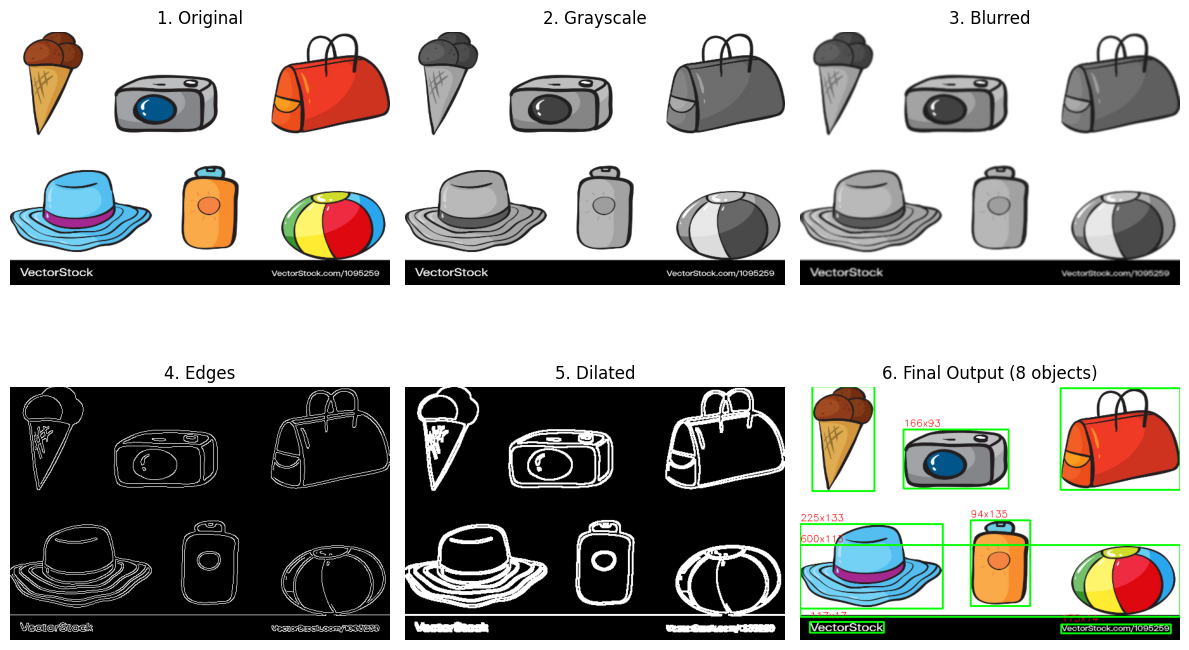

Objects detected: 8
Latency: 0.0623 seconds
Inference Time: 0.000727 seconds


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import time

# Read image
img = cv2.imread(image_path)
img = cv2.resize(img, (600, 400))

original = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# ---------------- LATENCY START ----------------
start_time = time.time()

# 1. Grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 2. Blur
blur = cv2.GaussianBlur(gray, (5,5), 0)

# 3. Edge Detection
edges = cv2.Canny(blur, 50, 150)

# 4. Dilation
kernel = np.ones((3,3), np.uint8)
dilated = cv2.dilate(edges, kernel, iterations=1)

# ---------------- OBJECT DETECTION ----------------
contours, _ = cv2.findContours(dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

output = original.copy()
object_count = 0

for cnt in contours:
    area = cv2.contourArea(cnt)

    if area > 1000:  # filter noise
        x, y, w, h = cv2.boundingRect(cnt)
        object_count += 1

        # Draw bounding box
        cv2.rectangle(output, (x,y), (x+w,y+h), (0,255,0), 2)

        # Measurement text
        cv2.putText(output, f"{w}x{h}", (x,y-5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,0,0), 1)

# ---------------- LATENCY END ----------------
end_time = time.time()
latency = end_time - start_time

# ---------------- INFERENCE TIME ----------------
inf_start = time.time()

_ = cv2.findContours(dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

inf_end = time.time()
inference_time = inf_end - inf_start

# ---------------- DISPLAY ----------------
titles = [
    "1. Original",
    "2. Grayscale",
    "3. Blurred",
    "4. Edges",
    "5. Dilated",
    f"6. Final Output ({object_count} objects)"
]

images = [
    original,
    gray,
    blur,
    edges,
    dilated,
    output
]

plt.figure(figsize=(12,8))

for i in range(6):
    plt.subplot(2,3,i+1)
    if i in [1,2,3,4]:
        plt.imshow(images[i], cmap='gray')
    else:
        plt.imshow(images[i])
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

# ---------------- RESULTS ----------------
print("Objects detected:", object_count)
print("Latency:", round(latency, 4), "seconds")
print("Inference Time:", round(inference_time, 6), "seconds")